<a href="https://colab.research.google.com/github/helenachen03/mortality-rate-prediction/blob/main/notebooks/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import and setup

In [ ]:
#pip install lifelines

In [ ]:
#pip install vl-convert-python

In [ ]:
#pip install xgboost

In [ ]:
#pip install shap

In [ ]:
#pip install graphviz

In [ ]:
#from google.colab import drive
import os
import pandas as pd
import altair as alt
import numpy as np
import graphviz
from numpy.random.mtrand import f
import matplotlib.pyplot as plt
import sklearn
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import tree, linear_model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_auc_score, RocCurveDisplay, f1_score, precision_score, recall_score, confusion_matrix,  mean_squared_error, r2_score
import xgboost as xgb
import shap

from xgboost import XGBClassifier, XGBRegressor
from lifelines.utils import concordance_index

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Mount google drive
#drive.mount('/content/drive')
#base_path = '/content/drive/My Drive/Group Project/'


#If running locally, uncomment this bock and comment out google drive block
base_path = ''
base_path = f'{base_path}Data/'

#Make needed directories
try:
  os.mkdir(f'{base_path}Figures')
except:
  None

# Load and Clean NHANES Mortality dataset

In [ ]:
nhanes_ndi_df = pd.read_csv(f'{base_path}nhanes_ndi_df.csv')
nhanes_ndi_df.head()
print(nhanes_ndi_df.shape)

(26453, 37)


### Optional test on smaller subsample

In [ ]:
#Uncomment line below to test notebook on smaller dataset
#nhanes_ndi_df = nhanes_ndi_df.sample(1000)
#nhanes_ndi_df = nhanes_ndi_df.sample(100)

MORTSTAT is measured at variable time points. PERMTH_INT and PERMTH_EXM measure mow many months mortality was measured from NHANES interview and exam, respectively. Let's explore the PERMTH variables to look for a feasible surivial endpoint to use as our outcome variable.

In [ ]:
median_survival = nhanes_ndi_df[['year','MORTSTAT','PERMTH_INT','PERMTH_EXM']].groupby(['year','MORTSTAT'],as_index=False).median()

chart = alt.Chart(median_survival,title='Median Suvival').mark_bar(width=30).encode(
        x=alt.X('year',title = 'NHANES cycle'),
        y=alt.Y('PERMTH_INT', title = 'Outcome Measured at (Months)'),
        color='MORTSTAT:N',
    ).properties(width=400)

chart.show()
#Save to file
chart.save(f'{base_path}Figures/median_survival_bymortstat_{len(nhanes_ndi_df)}.png')

alt.Chart(...)

In [ ]:
median_survival[median_survival['MORTSTAT']==0]

,year,MORTSTAT,PERMTH_INT,PERMTH_EXM
0,1999,0.0,240.0,239.0
2,2001,0.0,217.0,216.0
4,2003,0.0,193.0,192.0
6,2005,0.0,169.0,168.0
8,2007,0.0,145.0,144.0
10,2009,0.0,121.0,120.0
12,2011,0.0,97.0,96.0
14,2013,0.0,73.0,72.0
16,2015,0.0,49.0,48.0
18,2017,0.0,25.0,24.0


As we can see time to measurement decreases in more recent years. This makes sense given that this data comes from a 2019 public release. Median survival among the living for 2017 is 24 months. As survial endpoints get longer, balance improves (to a point) but sample size decreases.

## Feature Engineering

The function below adds a months_survial feature for a chosen endpoint, in months

In [ ]:
def get_months_survival(input_df,months):
  df = input_df.copy()
  #fill outcome column
  #True if follow up >= months, False if confirmed death and < months, else nan
  df[f'{months}_month_survival'] = np.nan
  df.loc[df['PERMTH_INT']>=months, f'{months}_month_survival'] = 1 #True
  df.loc[(df['MORTSTAT']==1)&(df['PERMTH_INT']<months), f'{months}_month_survival'] = 0 #False
  #drop nan
  df = df.loc[df[f'{months}_month_survival'].notna()]
  return df

nhanes_ndi_24 = get_months_survival(nhanes_ndi_df,24)
#Look at the tail to see thru which year data were kept
nhanes_ndi_24[nhanes_ndi_24['MORTSTAT']==0]

,SEQN,ELIGSTAT,MORTSTAT,PERMTH_INT,PERMTH_EXM,year,RIAGENDR,RIDAGEYR,RIDRETH1,DMDEDUC2,...,LBXTC,LBDTCSI,LBXGLU,LBXGH,LBDHDDSI,LBDHDD,LBDGLUSI,bpsx_mean,bpdi_mean,24_month_survival
1,5,1,0.0,244.0,244.0,1999,1.0,49.0,3.0,5.0,...,279.0,7.21,99.9,5.5,NaN,NaN,NaN,122.000000,82.666667,1.0
2,7,1,0.0,237.0,236.0,1999,2.0,59.0,4.0,2.0,...,245.0,6.34,85.6,5.8,NaN,NaN,NaN,125.333333,80.000000,1.0
4,12,1,0.0,236.0,236.0,1999,1.0,37.0,3.0,4.0,...,156.0,4.03,82.9,5.2,NaN,NaN,NaN,176.666667,102.000000,1.0
5,15,1,0.0,231.0,231.0,1999,2.0,38.0,3.0,5.0,...,199.0,5.15,98.8,4.6,NaN,NaN,NaN,108.000000,68.666667,1.0
6,20,1,0.0,245.0,244.0,1999,2.0,23.0,1.0,1.0,...,145.0,3.75,90.6,4.7,NaN,NaN,NaN,102.666667,58.666667,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26441,102918,1,0.0,32.0,31.0,2017,1.0,33.0,3.0,3.0,...,147.0,3.80,96.0,5.2,1.27,49.0,5.33,102.000000,68.000000,1.0
26446,102934,1,0.0,37.0,36.0,2017,1.0,48.0,4.0,3.0,...,180.0,4.65,99.0,5.2,1.16,45.0,5.50,NaN,NaN,1.0
26448,102947,1,0.0,31.0,31.0,2017,1.0,75.0,4.0,5.0,...,143.0,3.70,85.0,5.8,1.81,70.0,4.72,154.000000,80.000000,1.0
26450,102952,1,0.0,35.0,34.0,2017,2.0,70.0,5.0,3.0,...,119.0,3.08,158.0,7.4,1.55,60.0,8.77,139.333333,73.333333,1.0


Let's explore a few survial endpoints and assess class balance

In [ ]:

def outcome_balance(df):
  balance_df = pd.DataFrame(columns=['endpoint','True','False'])
  endpoints = np.linspace(24,12*20,10)
  for e in endpoints:
    df = get_months_survival(df,e)
    counts = df[f'{e}_month_survival'].value_counts()
    true, false = counts.get(1,0), counts.get(0,0)
    balance_df.loc[len(balance_df)] = [e,true,false]

  balance_df['True/False'] = balance_df['True']/balance_df['False']
  balance_melt = balance_df.melt(id_vars=['endpoint'],value_vars=['True','False'])

  chart = alt.Chart(balance_melt, title = 'Outcome Balance').mark_bar(width=20).encode(
    x=alt.X('endpoint:N',axis=alt.Axis(values=endpoints,title='Endpoint (months)')),
    xOffset='variable',
    y=alt.Y('value', title='Count'),
    color=alt.Color('variable',title='Survival')).properties(width=600)

  chart.show()
  #Save to file
  chart.save(f'{base_path}Figures/outcome_balance_{len(df)}.png')


  return balance_df

outcome_balance_df = outcome_balance(nhanes_ndi_df)
outcome_balance_df

alt.Chart(...)

,endpoint,True,False,True/False
0,24.0,24718.0,556.0,44.456835
1,48.0,21389.0,1239.0,17.263115
2,72.0,18234.0,1872.0,9.740385
3,96.0,15083.0,2451.0,6.153815
4,120.0,12009.0,2919.0,4.114080
5,144.0,9038.0,3308.0,2.732164
6,168.0,6516.0,3592.0,1.814031
7,192.0,4395.0,3861.0,1.138306
8,216.0,2565.0,4007.0,0.640130
9,240.0,767.0,4082.0,0.187898


In [ ]:
most_balanced_endpoint = outcome_balance_df.iloc[outcome_balance_df['True/False'].argmin()]['endpoint']
most_balanced_endpoint
print(f'Most balanced at {most_balanced_endpoint} months, or {most_balanced_endpoint/12} years')

Most balanced at 240.0 months, or 20.0 years


## Choose survial endpoint

A trade off between sample size and class balance exists here.
We'll 10-year survival in the interest of preserving both balance and sample size.

In [ ]:
months = 120
nhanes_ndi_endpoint_df = get_months_survival(nhanes_ndi_df,months=months)

In [ ]:
nhanes_ndi_endpoint_df.nunique().sort_values().head(10)

ELIGSTAT               1
120_month_survival     2
MORTSTAT               2
RIAGENDR               2
SMQ020                 4
RIDRETH1               5
DMDEDUC2               7
year                  10
BPXDI1                59
BPXDI3                60
dtype: int64

Our earlier cleaning steps removed all variation from ELIGSTAT. Let's drop that and SEQN before training the model. We'll also drop MORTSTAT and PERMTH features to prevent data leakage.

In [ ]:
nhanes_ndi_endpoint_df = nhanes_ndi_endpoint_df.drop(['ELIGSTAT','SEQN','MORTSTAT','PERMTH_INT','PERMTH_EXM','year'],axis=1)

In [ ]:
counts = nhanes_ndi_endpoint_df[f'{months}_month_survival'].value_counts()
display(counts)
print('Imbalance ratio =',counts.max()/counts.min())

120_month_survival
1.0    12009
0.0     2919
Name: count, dtype: int64

Imbalance ratio = 4.114080164439876


We have some class imbalance with positive cases in the minority. This may be within the margin our forest model can handle, though. This will be important to consider in our evaluation metrics.

## Test Train Split

In [ ]:
def tts(df=nhanes_ndi_endpoint_df,y_col=f'{months}_month_survival'):
  x = df.drop(columns=[y_col])
  y = df[y_col]
  return train_test_split(x, y, test_size=0.2,random_state=42)

In [ ]:
x_train, x_test, y_train, y_test = tts(nhanes_ndi_endpoint_df)

# Train and Tune Models

## Decision Tree

Decison tree is our simplest classifier. These supervised models work similar to flowcharts. Because of this, they are often good for fitting nonlinear relationships. They are also less affected by null values and scaling than other methods. First we'll fit a base model with default hyperparamters, then tune it by performing a cross validation gridsearch to find optimal hyperparameters.

In [ ]:
def get_base_tree(x_train=x_train,y_train=y_train):
  features = x_train.columns
  x_train = x_train[features]
  model = tree.DecisionTreeClassifier(random_state=42).fit(x_train,y_train)
  return model
base_tree = get_base_tree()

In [ ]:
tree_grid = {'max_features': ['sqrt', 'log2'],
             'max_depth': [2,4, 5, 6, 7, 8, 10],
             'criterion': ['gini', 'entropy', 'log_loss'],
             'splitter': ['best', 'random'],
             'class_weight': ['balanced', None],
             'random_state': [42]}

In [ ]:
def model_tuner(base_model, param_grid,x_train=x_train,y_train=y_train,fillna=False):
  if fillna:
    x_train = x_train.fillna(x_train.mean())
  #CV search for best params
  CV_mod = GridSearchCV(estimator= base_model,
                      param_grid=param_grid, cv= 5, n_jobs=-1)
  CV_mod.fit(x_train, y_train)
  params =  CV_mod.best_params_

  #Fit new model with best params
  tuned_model = type(base_model)(**params)
  tuned_model.fit(x_train,y_train)

  return tuned_model


In [ ]:
tuned_tree = model_tuner(base_tree,tree_grid)
print(tuned_tree)

DecisionTreeClassifier(max_depth=2, max_features='log2', random_state=42,
                       splitter='random')


## Random Forest

The next most complex classifier is the random forest. As the name implies, forests are comprised of many trees. Each tree in the forest "votes" on a predicted class, and the overall classification is determined by majority vote. Unlike decision tree, the sklearn RandomForestClassifier cannot handle nan values natively so we will have to specify a strategy. Given that sparse featuers were dropped in the cleaning notebook, we will opt for a simple mean imputation.

In [ ]:
def get_base_rf(x_train=x_train,y_train=y_train):
  x_train = x_train.fillna(x_train.mean())
  model = RandomForestClassifier(random_state=42)
  model.fit(x_train, y_train)
  return model

base_rf = get_base_rf()

In [ ]:
rf_grid = {
    'max_depth': [None, 10],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 0.5],
    'random_state': [42]
}


In [ ]:
tuned_rf = model_tuner(base_rf,rf_grid)
print(tuned_rf)

RandomForestClassifier(max_features=0.5, min_samples_leaf=5, random_state=42)


## Gradient Boosted Tree

The next most complex classifier is a gradient boosted tree. Similar to random forests, these models are made of many component trees. However, rather than a majority vote, these trees are trained in sequence. The first tree is trained on the test set, and each subsequent tree is trained on the errors from the last.

In [ ]:
def get_base_xgb(x_train=x_train,y_train=y_train):
 xgb = XGBClassifier()
 xgb.fit(x_train, y_train)
 return xgb

base_xgb = get_base_xgb()

In [ ]:
xgb_grid ={'learning_rate': [0.05,0.1,0.2],
            'max_depth' : [3,4,5,6,None],
            'min_child_weight': [1, 3, 5],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.7, 1.0],
            'random_state': [42]
           }

In [ ]:
tuned_xgb = model_tuner(base_xgb, xgb_grid,x_train=x_train,y_train=y_train)
print(tuned_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` instead. 
  warnings.warn(
/var/folders/8l/ywk_xc6n7q56qnw1fvkpzm5h0000gn/T/ipykernel_28018/4110694646.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


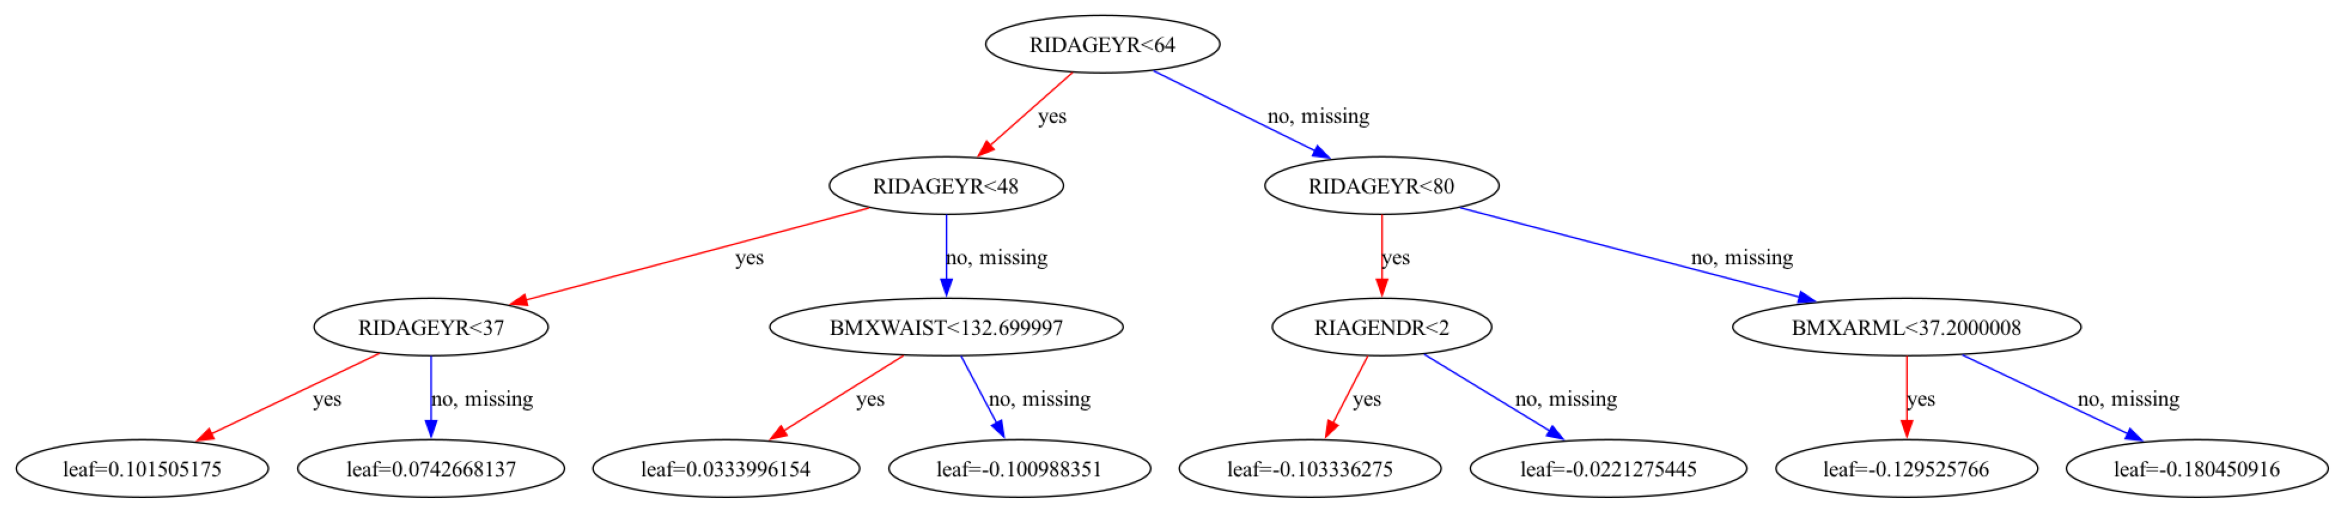

In [ ]:
fig, ax = plt.subplots(figsize=(30, 30))
xgb.plot_tree(tuned_xgb, num_trees=4, ax=ax)
fig.show()

## Support Vector Classifier

In [ ]:
def base_svc(x_train=x_train,y_train=y_train):
  x_train = x_train.fillna(x_train.mean())
  clf = SVC(kernel='rbf', C=1.0)
  clf.fit(x_train, y_train)
  return clf

base_svc()

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
svc_grid = {
    'C': [1, 10,100],
    'kernel': ['rbf'],
    'gamma': ['scale'],
    'class_weight': ['balanced'],
    'random_state': [42],
}


In [ ]:
tuned_svc = model_tuner(base_svc(),svc_grid,fillna=True)
print(tuned_svc)

SVC(C=100, class_weight='balanced', random_state=42)


## K-Nearest Neighbor

In [ ]:
def get_base_knn(x_train=x_train,y_train=y_train):
  x_train = x_train.fillna(x_train.mean())
  clf = KNeighborsClassifier(n_neighbors=3)
  clf.fit(x_train, y_train)
  return clf
base_knn = get_base_knn()

In [ ]:
knn_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}


In [ ]:
tuned_knn = model_tuner(base_knn,knn_grid,fillna=True)
print(tuned_knn)

KNeighborsClassifier(metric='manhattan', n_neighbors=9, weights='distance')


# Evaluate Models

## Classifiers

In [ ]:
#clfs = {'base_tree':base_tree,'tuned_tree':tuned_tree, 'base_rf':base_rf,'tuned_rf':tuned_rf, 'base_xgb':base_xgb,'tuned_xgb':tuned_xgb}
clfs = {'tuned_tree': tuned_tree, 'tuned_rf': tuned_rf, 'tuned_xgb': tuned_xgb, 'tuned_knn':tuned_knn,'tuned_svc':tuned_svc}

### Evaluation Metrics

In [ ]:
def model_scoring(model,x_train=x_train,y_train=y_train):
  scoring = ['precision','recall','f1','roc_auc']
  try:
    result = sklearn.model_selection.cross_validate(model,x_train,y_train, scoring=scoring)
  except:
    x_train = x_train.fillna(x_train.mean())
    result = sklearn.model_selection.cross_validate(model,x_train,y_train, scoring=scoring)
  return result

**Overall scoring dataframe**

This may take some time as cross validation is performed for each model.

In [ ]:
def get_scoring_df(model_dict):
  scoring_lis = {}
  #Get scoring of each model
  for model_name, model in model_dict.items():
    scoring_lis[model_name] = (model_scoring(model))

  idx = (model_scoring(model)).keys()
  cols = model_dict.keys()
  scoring_df = pd.DataFrame(columns = cols)
  for i in idx:
    for c in cols:
      scoring_df.loc[f'{i}_mean',c] = scoring_lis[c][i].mean()
      scoring_df.loc[f'{i}_std',c] = scoring_lis[c][i].std()
  return scoring_df

scoring_df = get_scoring_df(clfs)
scoring_df.to_csv(f'{base_path}clf_scoring_df.csv')

In [ ]:
scoring_df.round(3)

,tuned_tree,tuned_rf,tuned_xgb,tuned_knn,tuned_svc
fit_time_mean,0.00255,4.615768,0.1095,0.002381,1.689724
fit_time_std,0.000501,0.046889,0.000585,0.000288,0.047746
score_time_mean,0.004703,0.043097,0.006266,0.186164,0.753193
score_time_std,0.000693,0.001402,0.000233,0.011731,0.021288
test_precision_mean,0.870841,0.892888,0.897924,0.856711,0.945002
test_precision_std,0.00181,0.003145,0.003839,0.003316,0.00455
test_recall_mean,0.948991,0.946597,0.947534,0.94899,0.804602
test_recall_std,0.005617,0.008518,0.009567,0.005429,0.00981
test_f1_mean,0.908233,0.918934,0.92203,0.900476,0.869132
test_f1_std,0.003312,0.00402,0.004518,0.001923,0.006042


The simple tree model appears to benefit the most from tuning. This makes sense given these are the most prone to overfitting.

**ROC AUC Comparison**

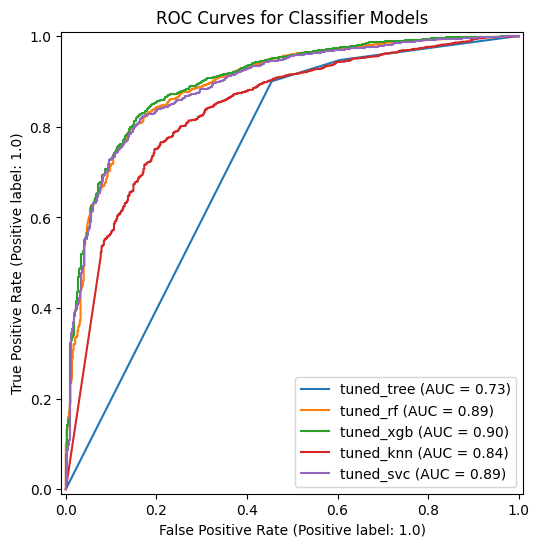

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

tuned_models = {'tuned_tree':tuned_tree,'tuned_rf':tuned_rf, 'tuned_xgb':tuned_xgb}

for name, model in clfs.items():
  try:
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax=ax, name=name)
  except:
    x_test = x_test.fillna(x_test.mean())
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax=ax, name=name)

ax.set_title(f"ROC Curves for Classifier Models")
ax.legend()
plt.show()

#Save figure
fig.savefig(f'{base_path}roc_curves_n={len(x_train)}.png')


### SHAP Feature importance

Code adapted form this tutorial: https://xgboosting.com/explain-xgboost-predictions-with-shap/


Let's look just at our top perfomring model.

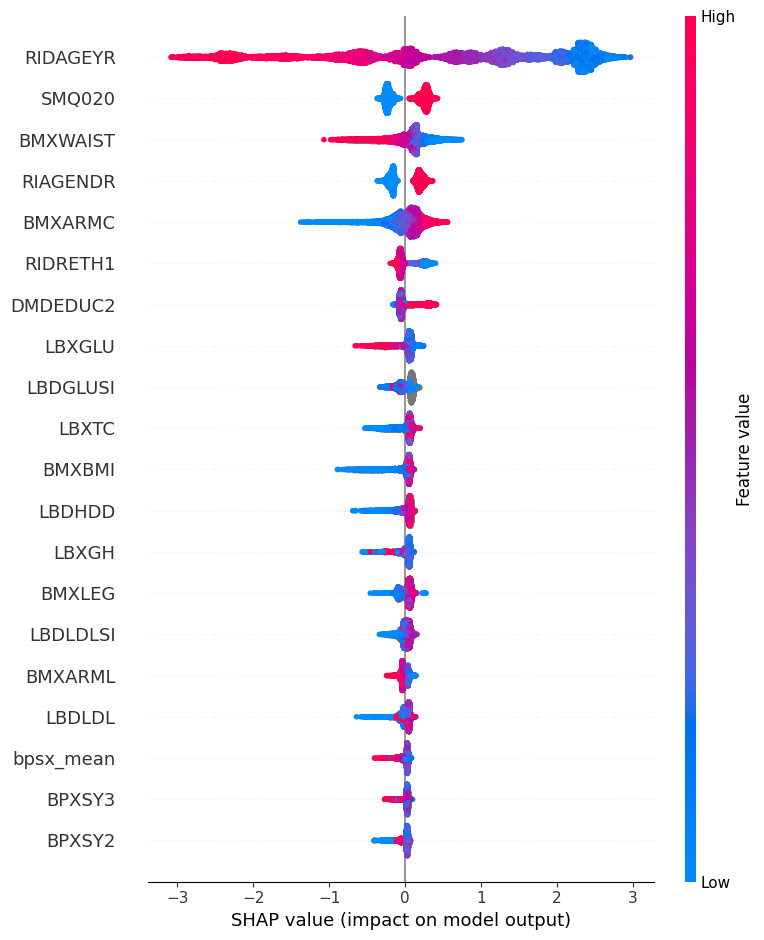

In [ ]:
explainer = shap.TreeExplainer(tuned_xgb)
shap_values = explainer.shap_values(x_train)

shap.summary_plot(shap_values, x_train)

### Ablation analysis

This will take a while to run as each feature is iteratively dropped to refit each model.

In [ ]:
def ablation_analysis(tuned_model,
                      x_train = x_train,
                      x_test = x_test,
                      fillna=False):

  ablation_df = pd.DataFrame(columns=['feature','score','ablated-base score'])

  if fillna:
    x_train = x_train.fillna(x_train.mean())
    x_test = x_test.fillna(x_test.mean())
  #Get base score
  preds = tuned_model.predict(x_test)
  base_score = sklearn.metrics.roc_auc_score(y_test,preds)

  #Run ablation
  rs = np.random.default_rng(42) #set randomstate for numpy
  sort = x_train.columns.tolist() #will use to force column sorting as needed

  for feat in x_train.columns:
    #Make copies to prevent in-place changes in loop
    x_train_ablated, x_test_ablated = x_train.copy(), x_test.copy()
    model_copy = clone(tuned_model) #prevent multiple fits on same object
    #Scramble values to 'confuse' model
    x_train_ablated[feat] = rs.permutation(x_train_ablated[feat])
    x_test_ablated[feat] = rs.permutation(x_test_ablated[feat])
    #Fit and get score
    ablated_model = model_copy.fit(x_train_ablated,y_train)
    #ablated_score = model_scoring(ablated_model,x_train= x_train_ablated)['test_f1'].mean()
    preds = ablated_model.predict(x_test_ablated)
    ablated_score = roc_auc_score(y_test,preds)
    #Store values in ablation df
    ablation_df.loc[len(ablation_df.index)] = [feat,ablated_score,ablated_score-base_score]

  ablation_df = ablation_df.sort_values(by='score',ascending=True)

  fig = alt.Chart(ablation_df).mark_bar().encode(
    x=alt.X('feature',sort=ablation_df['feature']),
    y='ablated-base score')
  display(fig)
  #Save Figure
  model_type = str(type(tuned_tree)).split('classes.')[1]
  fig.save(f'{base_path}Figures/ablation_analysis_{model_type}_n={len(x_train)}.png')
  return ablation_df

In [ ]:
#print('Ablation analysis for tree')
#ablation_analysis(tuned_tree).head()

In [ ]:
#print('Ablation analysis for random forest')
#ablation_analysis(tuned_rf).head()

In [ ]:
print('Ablation analysis for xgb classifier')
ablation_analysis(tuned_xgb).head()

Ablation analysis for xgb classifier


alt.Chart(...)

,feature,score,ablated-base score
1,RIDAGEYR,0.642716,-0.101403
10,BMXWAIST,0.733412,-0.010708
6,BMXBMI,0.733412,-0.010708
29,bpsx_mean,0.734036,-0.010084
4,BMXWT,0.734478,-0.009642


Age appears to have hte biggest impact. There are some small positive values on the right tail, which implies our feature selection could have been stronger. Omitting these features may force the model to rely on better or less noisy features.

In [ ]:
#print('Ablation analysis for knn classifier')
#ablation_analysis(tuned_knn,fillna=True).head()

In [ ]:
#print('Ablation analysis for svc classifier')
#ablation_analysis(tuned_svc,fillna=True).head()

###  Failure Analysis

The failure analysis function below returns a confusion matrix and a fail_df containing only cases where the classifier failed to correctly predict labels. For each classifier, 5 rows from fail_df are randomly sampled.

In [ ]:
def clf_failure_analysis(tuned_model,
                     x_test=x_test,
                     y_test=y_test):
  #Add labels for predict and fail
  preds = tuned_model.predict(x_test)
  fail_df = x_test.copy()
  fail_df["true_label"] = y_test
  fail_df["pred_label"] = preds.round()
  fail_df['fail'] = fail_df['true_label']!=fail_df['pred_label']

  #Confusion Matrix
  cm = confusion_matrix(fail_df['true_label'], fail_df['pred_label'])
  cm = pd.DataFrame(cm, index=['Label False','Label True'], columns=['Predict False','Predict True'])

  #return CM and fail cases to sample
  return cm, fail_df[fail_df['fail']]

In [ ]:
#print('Failure analysis for decision tree')
#cm, fail_df = clf_failure_analysis(tuned_tree)
#display(cm)
#fail_df.sample(5)

In [ ]:
#print('Failure analysis for random forest')
#cm, fail_df = clf_failure_analysis(tuned_rf)
#display(cm)
#fail_df.loc[[5186,4828,19668]].T

In [ ]:
print('Failure analysis for xgb classifier')
cm, fail_df = clf_failure_analysis(tuned_xgb)
display(cm)
fail_df.sample(5)

Failure analysis for xgb classifier


,Predict False,Predict True
Label False,314,269
Label True,121,2282


,RIAGENDR,RIDAGEYR,RIDRETH1,DMDEDUC2,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,...,LBXGLU,LBXGH,LBDHDDSI,LBDHDD,LBDGLUSI,bpsx_mean,bpdi_mean,true_label,pred_label,fail
1984,2.0,85.0,3.0,3.0,52.9,148.0,24.15,34.9,36.8,26.6,...,97.8,5.3,1.40309,54.129316,6.08582,145.000000,70.000000,1.0,0,True
10186,2.0,45.0,4.0,4.0,118.1,173.1,39.41,42.5,39.6,41.5,...,75.0,9.1,1.03000,40.000000,4.16300,125.879620,69.325590,0.0,1,True
17142,2.0,63.0,4.0,5.0,54.6,150.4,24.10,35.0,34.0,28.3,...,102.0,5.7,1.24000,48.000000,5.66200,108.000000,62.000000,0.0,1,True
21207,1.0,66.0,3.0,5.0,87.5,179.1,27.30,42.4,37.8,32.4,...,105.0,5.6,1.09000,42.000000,5.83000,115.333333,70.000000,0.0,1,True
360,2.0,80.0,3.0,3.0,53.4,154.6,22.34,39.3,33.9,27.7,...,91.7,5.0,1.40309,54.129316,6.08582,140.000000,66.666667,1.0,0,True


In [ ]:
fail_df.loc[[5186,4828,19668]].T

,5186,4828,19668
RIAGENDR,1.0,2.0,1.0
RIDAGEYR,55.0,81.0,56.0
RIDRETH1,1.0,3.0,4.0
DMDEDUC2,4.0,3.0,2.0
BMXWT,72.7,49.7,59.5
BMXHT,159.0,157.7,174.4
BMXBMI,28.76,19.98,19.6
BMXLEG,36.2,35.7,37.8
BMXARML,36.5,35.2,37.0
BMXARMC,32.0,23.5,27.1


See three examples of failures from the random forest model above.
1. 55 yo Mexican American Male with less than 9th grade eduction, BMI 28.6, high blood pressure, high blood sugar, elevated triglycerides and LDL cholesterol was predicted false for 10-year survial when the actual value was true. (False negative)
2. An 81 yo non-hispanic white female with high school/GED level education, normal BMI, high blood pressure, normal lab values was predicted as true for 10-year survival when the actual value was false. (False positive)
3. 56 yo other/multiracial male with 9-11th grade education, with normal BMI, mildly high blood pressure, and high triglycerides (other labs normal) was predicted false for 10-year survival when the actual value was True. (False negative)

Based on these three alone, it appears the model may not weigh age heavily enough relative to other demographics and lab values. The model may be biased toward shorter life expectancy for non-white males.
To address false positives among those with advanced age, additional feature engineering may help capture interactions between age and other factors.
To address false negatives among non-white subjects, weighting could be used to ensure more diverse samples are included in training data. If the data are insufficient, the model could also be trained without ethnicity (RIDRETH1) as a training feature.

### Sensitivity Analysis

For this analysis we'll just look at the top performer, random forest.

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    tuned_xgb, x_train, y_train,
    train_sizes=np.linspace(0.01,1.0,10), #from 1% to 100% of train data used
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

plot_df = pd.DataFrame({
    'train_size': train_sizes,
    'train_mean': train_scores.mean(axis=1),
    'val_mean': val_scores.mean(axis=1),
    'val_std':val_scores.std(axis=1),
})

In [ ]:
plot_df['val_upper'] = plot_df['val_mean'] + plot_df['val_std']
plot_df['val_lower'] = plot_df['val_mean'] - plot_df['val_std']

line = alt.Chart(plot_df,title='GBT Learning Curve').mark_line().encode(
    x=alt.X('train_size',title='Training set size'),
    y=alt.Y('val_mean', scale=alt.Scale(domain=[0.8, 1.0]),title='ROC AUC Score')
)

band = alt.Chart(plot_df).mark_area(opacity=0.3).encode(
    x=alt.X('train_size'),
    y=alt.Y('val_upper'),
    y2=alt.Y2('val_lower')
)

fig = alt.layer(line,band).properties(width=300,height=300)
fig.show()
fig.save(f'{base_path}Figures/learning_curve.png')

alt.LayerChart(...)

#Exploratory task: survival regression

## XGB Survival Regression
Code adapted from this source:
https://xgboosting.com/xgboost-for-survival-analysis-cox-model/

The classifiers above share a common goal, to predict a binary outcome based on a single survival endpoint. Engineering that outcome variable collapses a lot of information into a single number. The XGBoost regressor with survival objective seeks to adress this by using both mortality labels and time of measurement. For a given x_input, it will predict a mortality likelihood score.

This task is being done for exploration, though cannot be directly compared to classifiers.

### Train and tune

In [ ]:
#First we need to clean and split the NHANES_ndi dataframe
#Remember we've been working from _endpoint dataframe so far

def xgbs_tts(df):
  #drop data-leakage
  df = df.drop(['ELIGSTAT','SEQN','year'],axis=1)
  #drop nan from mortality and survial
  df = df.dropna(subset=['MORTSTAT','PERMTH_INT'])
  #TTS
  x_train, x_test, y_train, y_test = tts(df,'MORTSTAT')
  #Separate surivial time sets
  st_train = x_train['PERMTH_INT']
  st_test = x_test['PERMTH_INT']
  #Drop survival from x sets
  x_train = x_train.drop(['PERMTH_INT','PERMTH_EXM'],axis=1)
  x_test = x_test.drop(['PERMTH_INT','PERMTH_EXM'],axis=1)
  #Force column alignment
  x_train = x_train[sorted(x_test.columns)]
  x_test = x_test[sorted(x_test.columns)]
  return x_train, x_test, y_train, y_test, st_train, st_test

In [ ]:
x_train2, x_test2, y_train2, y_test2, st_train, st_test = xgbs_tts(nhanes_ndi_df)

In [ ]:
def get_base_xgbs(x_train=x_train2,survival_time_train = st_train):
  #Initialize Model
  model = XGBRegressor(objective='survival:cox',
                     eval_metric='cox-nloglik',
                     tree_method='hist')
  #Fit Model
  model.fit(x_train, survival_time_train)

  return model
base_xgbs = get_base_xgbs()

In [ ]:
tuned_xgbs = model_tuner(base_xgbs,xgb_grid,x_train=x_train2,y_train=y_train2)
print(tuned_xgbs)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


In [ ]:
tuned_xgbs

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Evaluation Metrics


Unlike the classifiers which can be evaluated with conventional metrics such as accuracy, precision, recall, and F1 score, the survival regression is evaluated using concordance. This metric compares the ranked mortality risk scores to the ranked survival time for confirmed deaths. A pairwise boolean comparison is made for each combination and averaged to a single sore.

In [ ]:
def xgbs_concordance(fitted_model,
                  x_test=x_test2,
                  survival_time_test=st_test,
                  y_test=y_test2):

    c_index = concordance_index(
        survival_time_test,
        -fitted_model.predict(x_test),
        y_test
                            )
    return c_index
c_base = xgbs_concordance(base_xgbs)
c_tuned = xgbs_concordance(tuned_xgbs)

print('Base concordance: ',round(c_base,3))
print('Tuned concordance: ',round(c_tuned,3))

Base concordance:  0.686
Tuned concordance:  0.84


Showing RMSE and R-squared for an example. These are poor metrics for xgb survival regression which predicts a float, while y_test is binary.

In [ ]:
y_pred = tuned_xgbs.predict(x_test2)
rmse = np.sqrt(mean_squared_error(y_test2, y_pred))
r2 = r2_score(y_test2, y_pred)

print('RMSE = ', round(rmse,3))
print('r^2 = ', round(r2,3))

RMSE =  0.289
r^2 =  0.38


### Feature Importance

Code and visualization adapted from this tutorial: https://www.geeksforgeeks.org/machine-learning/xgboost-for-regression/


In [ ]:
importance = tuned_xgbs.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame()
importance_df['feature'] = importance.keys()
importance_df['Importance Score'] = importance.values()
importance_df = importance_df.sort_values(by='Importance Score',ascending=False)

fig = alt.Chart(importance_df.head(20), title = f'XGB Regression: Top 20 Features').mark_bar(width=25).encode(
    x=alt.X('feature',sort=importance_df['feature']),
    y='Importance Score').properties(width=600,height=400)

fig.show()

alt.Chart(...)